## Introduction ##
This project focuses on analyzing the AI and Data Science job market using a real-world dataset. The objective is to understand job trends, required skills, salary distribution, and hiring patterns using data analytics techniques.

In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("Ai Job Market Dataset.csv")
df.head()

,job_id,job_title,company_size,company_industry,country,remote_type,experience_level,years_experience,education_level,skills_python,skills_sql,skills_ml,skills_deep_learning,skills_cloud,salary,job_posting_month,job_posting_year,hiring_urgency,job_openings
0,1,AI Engineer,Startup,Retail,Canada,Remote,Senior,2.0,Master,0.0,0.0,0.0,1.0,0.0,158322.0,6.0,2024.0,Low,4
1,2,Machine Learning Engineer,MNC,Technology,Australia,Hybrid,Mid,0.0,Bachelor,1.0,1.0,1.0,0.0,1.0,163666.0,11.0,2026.0,High,9
2,3,Machine Learning Engineer,MNC,Technology,Germany,Onsite,Mid,14.0,Master,1.0,0.0,1.0,0.0,1.0,158556.0,3.0,2026.0,High,9
3,4,Business Analyst,Startup,Healthcare,Germany,Remote,Mid,9.0,Master,0.0,1.0,0.0,1.0,1.0,95775.0,3.0,2025.0,High,7
4,5,Data Scientist,MNC,Healthcare,Germany,Hybrid,Mid,5.0,Master,1.0,1.0,1.0,0.0,0.0,111873.0,12.0,2021.0,Low,2


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10346 entries, 0 to 10345
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   job_id                10346 non-null  str    
 1   job_title             10345 non-null  str    
 2   company_size          10345 non-null  str    
 3   company_industry      10345 non-null  str    
 4   country               10345 non-null  str    
 5   remote_type           10345 non-null  str    
 6   experience_level      10345 non-null  str    
 7   years_experience      10345 non-null  float64
 8   education_level       10345 non-null  str    
 9   skills_python         10345 non-null  float64
 10  skills_sql            10345 non-null  float64
 11  skills_ml             10345 non-null  float64
 12  skills_deep_learning  10345 non-null  float64
 13  skills_cloud          10345 non-null  float64
 14  salary                10345 non-null  float64
 15  job_posting_month     10345 no

In [4]:
df.describe()

,years_experience,skills_python,skills_sql,skills_ml,skills_deep_learning,skills_cloud,salary,job_posting_month,job_posting_year,job_openings
count,10345.000000,10345.000000,10345.000000,10345.000000,10345.000000,10345.000000,10345.00000,10345.000000,10345.000000,10346.000000
mean,6.950507,0.493088,0.503045,0.507878,0.498018,0.511455,113438.22726,6.502465,2023.000387,10.007153
std,4.320054,0.499976,0.500015,0.499962,0.500020,0.499893,31389.20106,3.473441,1.996856,508.897567
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,45083.00000,1.000000,2020.000000,1.000000
25%,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,89715.00000,4.000000,2021.000000,3.000000
50%,7.000000,0.000000,1.000000,1.000000,0.000000,1.000000,113082.00000,6.000000,2023.000000,5.000000
75%,11.000000,1.000000,1.000000,1.000000,1.000000,1.000000,134894.00000,10.000000,2025.000000,7.000000
max,14.000000,1.000000,1.000000,1.000000,1.000000,1.000000,204143.00000,12.000000,2026.000000,51767.000000


In [5]:
df.columns

Index(['job_id', 'job_title', 'company_size', 'company_industry', 'country',
       'remote_type', 'experience_level', 'years_experience',
       'education_level', 'skills_python', 'skills_sql', 'skills_ml',
       'skills_deep_learning', 'skills_cloud', 'salary', 'job_posting_month',
       'job_posting_year', 'hiring_urgency', 'job_openings'],
      dtype='str')

In [6]:
#DATA CLEANING
#Column names clean
df.columns = df.columns.str.strip().str.lower().str.replace(" ","_")

In [7]:
#Missing values check
df.isnull().sum()

job_id                  0
job_title               1
company_size            1
company_industry        1
country                 1
remote_type             1
experience_level        1
years_experience        1
education_level         1
skills_python           1
skills_sql              1
skills_ml               1
skills_deep_learning    1
skills_cloud            1
salary                  1
job_posting_month       1
job_posting_year        1
hiring_urgency          1
job_openings            0
dtype: int64

In [8]:
#Drop Missing values
df = df.dropna()

In [9]:
df.isnull().sum()

job_id                  0
job_title               0
company_size            0
company_industry        0
country                 0
remote_type             0
experience_level        0
years_experience        0
education_level         0
skills_python           0
skills_sql              0
skills_ml               0
skills_deep_learning    0
skills_cloud            0
salary                  0
job_posting_month       0
job_posting_year        0
hiring_urgency          0
job_openings            0
dtype: int64

In [10]:
#Duplicates Remove
df = df.drop_duplicates(subset=df.columns.difference(['job_id']))

In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
#Data Type Check
df.dtypes

job_id                      str
job_title                   str
company_size                str
company_industry            str
country                     str
remote_type                 str
experience_level            str
years_experience        float64
education_level             str
skills_python           float64
skills_sql              float64
skills_ml               float64
skills_deep_learning    float64
skills_cloud            float64
salary                  float64
job_posting_month       float64
job_posting_year        float64
hiring_urgency              str
job_openings              int64
dtype: object

In [13]:
df['salary'] = df['salary'].fillna(0).astype(int)

In [14]:
#Data Type change
df['years_experience'] = df['years_experience'].fillna(0).astype(int)
df['skills_python'] = df['skills_python'].fillna(0).astype(int)
df['skills_sql'] = df['skills_sql'].fillna(0).astype(int)
df['skills_ml'] = df['skills_ml'].fillna(0).astype(int)
df['skills_deep_learning'] = df['skills_deep_learning'].fillna(0).astype(int)
df['skills_cloud'] = df['skills_cloud'].fillna(0).astype(int)
df['job_posting_month'] = df['job_posting_month'].fillna(0).astype(int)
df['job_posting_year'] = df['job_posting_year'].fillna(0).astype(int)
df['job_openings'] = df['job_openings'].fillna(0).astype(int)

In [15]:
df.head()

,job_id,job_title,company_size,company_industry,country,remote_type,experience_level,years_experience,education_level,skills_python,skills_sql,skills_ml,skills_deep_learning,skills_cloud,salary,job_posting_month,job_posting_year,hiring_urgency,job_openings
0,1,AI Engineer,Startup,Retail,Canada,Remote,Senior,2,Master,0,0,0,1,0,158322,6,2024,Low,4
1,2,Machine Learning Engineer,MNC,Technology,Australia,Hybrid,Mid,0,Bachelor,1,1,1,0,1,163666,11,2026,High,9
2,3,Machine Learning Engineer,MNC,Technology,Germany,Onsite,Mid,14,Master,1,0,1,0,1,158556,3,2026,High,9
3,4,Business Analyst,Startup,Healthcare,Germany,Remote,Mid,9,Master,0,1,0,1,1,95775,3,2025,High,7
4,5,Data Scientist,MNC,Healthcare,Germany,Hybrid,Mid,5,Master,1,1,1,0,0,111873,12,2021,Low,2


In [16]:
#Extra Spaces remove
df = df.apply(lambda x: x.str.strip() if x.dtype == "object" else x)

In [17]:
#EXPLORATORY DATA ANALYSIS (EDA)
#Top job roles
df['job_title'].value_counts().head(10)

job_title
Business Analyst             1773
AI Engineer                  1742
Machine Learning Engineer    1740
Data Analyst                 1711
Data Scientist               1703
Data Engineer                1676
Name: count, dtype: int64

In [18]:
#Avg Salary
df['salary'].mean()

np.float64(113438.22725954567)

In [19]:
#Jobs by loaction
df['country'].value_counts().head(10)

country
Germany      1498
Singapore    1490
Canada       1488
UK           1485
India        1470
USA          1459
Australia    1455
Name: count, dtype: int64

In [20]:
df['experience_level'].value_counts()

experience_level
Entry     3513
Senior    3420
Mid       3412
Name: count, dtype: int64

In [21]:
df['education_level'].value_counts().head(10)

education_level
Master      3529
PhD         3425
Bachelor    3391
Name: count, dtype: int64

In [22]:
#VISUALIZATION
#Libraries
import matplotlib.pyplot as plt

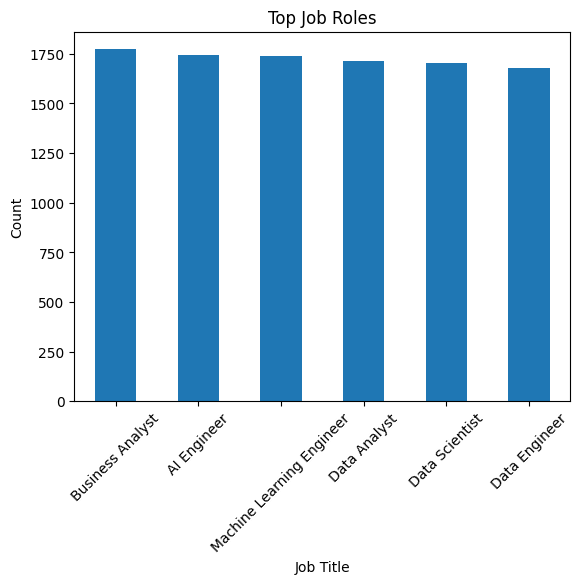

In [23]:
#Job roles chart
df['job_title'].value_counts().head(10).plot(kind='bar')
plt.title('Top Job Roles')
plt.xlabel('Job Title')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

Insight:-
Top job roles such as Business Analyst, AI Engineer, and Machine Learning Engineer dominate the job market, indicating strong demand for analytical and AI-related skills.

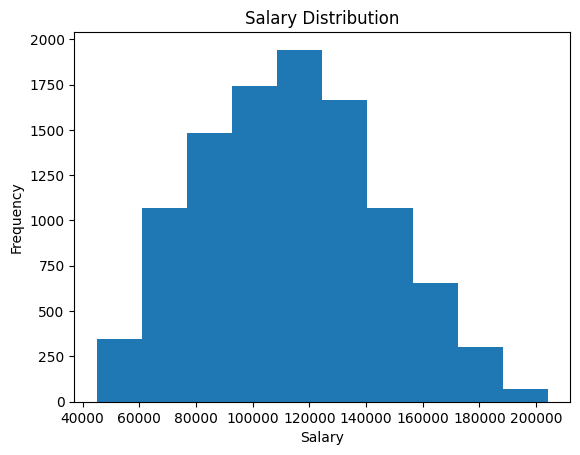

In [24]:
#Salary Distribution
df['salary'].plot(kind='hist')
plt.title("Salary Distribution")
plt.xlabel('Salary')
plt.ylabel('Frequency')
plt.show()

Insight:-
Most salaries are concentrated within a specific range, suggesting standardized compensation levels in the AI job market with fewer extreme salary values.

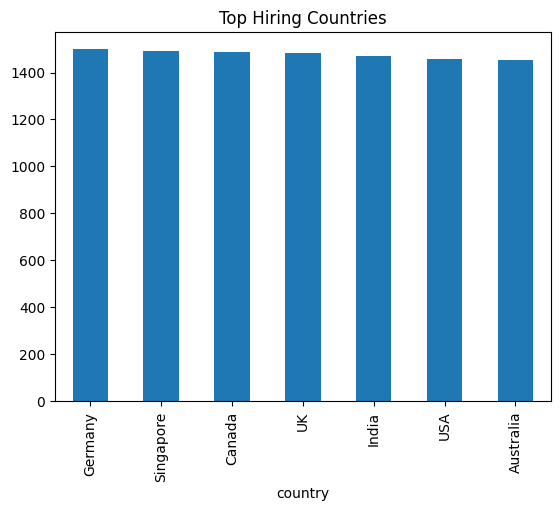

In [25]:
#jobs by country
df['country'].value_counts().head(10).plot(kind='bar')
plt.title('Top Hiring Countries')
plt.show()

Insight:-
Certain countries have significantly higher job openings, indicating strong growth and demand for AI professionals in those regions.

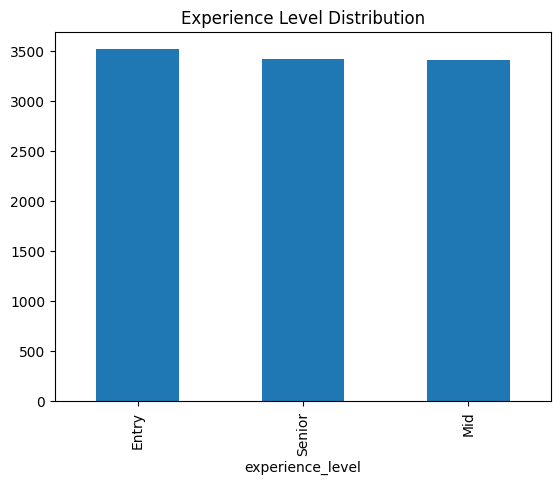

In [26]:
#Experience level distribution
df['experience_level'].value_counts().plot(kind='bar')
plt.title('Experience Level Distribution')
plt.show()

Insight:-
Mid-level and senior-level professionals are more in demand compared to entry-level candidates, highlighting the importance of experience in AI roles.

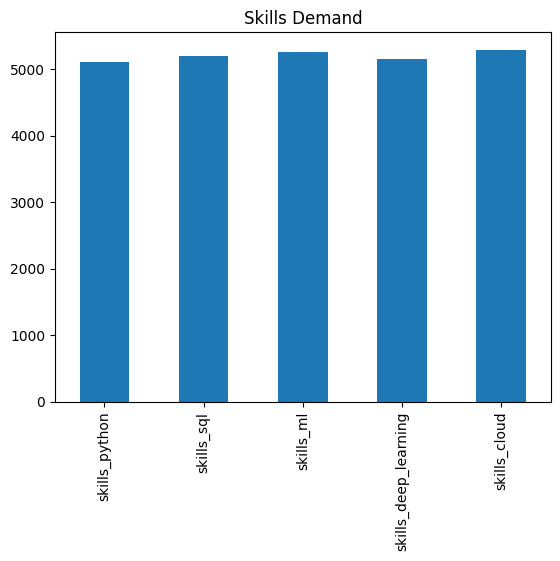

In [27]:
#Skills Demand
skills = ['skills_python','skills_sql','skills_ml','skills_deep_learning','skills_cloud']
df[skills].sum().plot(kind='bar')
plt.title("Skills Demand")
plt.show()

Insight:-
Python and SQL are the most in-demand skills, making them essential for data-related roles, while machine learning and cloud skills are also highly valued.

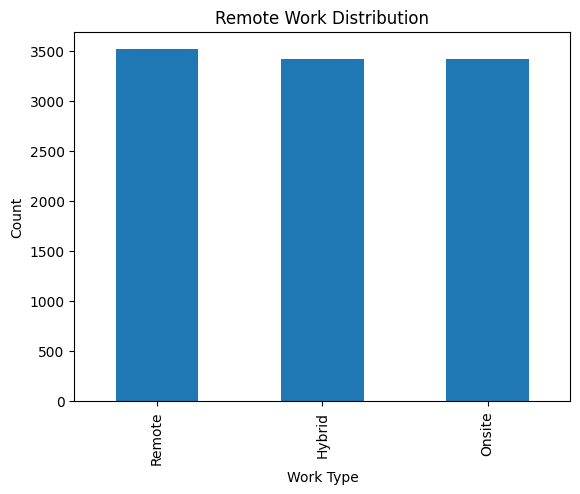

In [28]:
#Remote Work Type
df['remote_type'].value_counts().plot(kind='bar')
plt.title("Remote Work Distribution")
plt.xlabel("Work Type")
plt.ylabel("Count")
plt.show()

Insight:-
A significant number of jobs offer remote or hybrid work options, reflecting the growing trend of flexible work environments in the tech industry.

##Advance Analysis##

In [29]:
df.corr(numeric_only=True)

,years_experience,skills_python,skills_sql,skills_ml,skills_deep_learning,skills_cloud,salary,job_posting_month,job_posting_year,job_openings
years_experience,1.000000,0.006734,-0.000512,-0.018842,-0.010428,0.000218,-0.013266,-0.007646,-0.007753,-0.018421
skills_python,0.006734,1.000000,-0.004266,-0.001813,-0.005952,0.014725,0.009536,0.013968,0.009686,-0.005591
skills_sql,-0.000512,-0.004266,1.000000,0.008122,0.007081,0.004018,-0.003473,-0.002161,-0.018785,0.003133
skills_ml,-0.018842,-0.001813,0.008122,1.000000,0.007120,0.000316,0.232621,-0.005620,0.006872,0.012697
skills_deep_learning,-0.010428,-0.005952,0.007081,0.007120,1.000000,-0.010835,0.242504,-0.006273,-0.010166,0.022604
skills_cloud,0.000218,0.014725,0.004018,0.000316,-0.010835,1.000000,0.153725,-0.013560,-0.003104,0.008946
salary,-0.013266,0.009536,-0.003473,0.232621,0.242504,0.153725,1.000000,-0.013555,0.003028,0.005715
job_posting_month,-0.007646,0.013968,-0.002161,-0.005620,-0.006273,-0.013560,-0.013555,1.000000,-0.012698,0.011525
job_posting_year,-0.007753,0.009686,-0.018785,0.006872,-0.010166,-0.003104,0.003028,-0.012698,1.000000,-0.006783
job_openings,-0.018421,-0.005591,0.003133,0.012697,0.022604,0.008946,0.005715,0.011525,-0.006783,1.000000


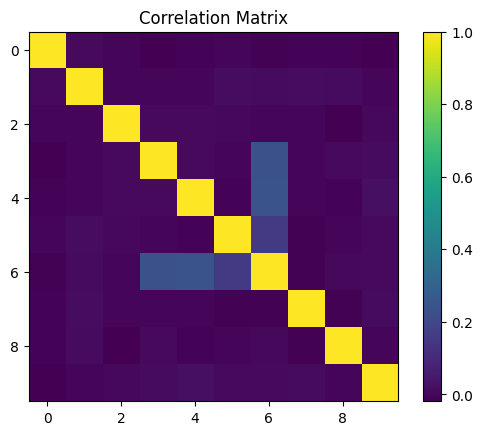

In [30]:
import matplotlib.pyplot as plt

plt.imshow(df.corr(numeric_only=True))
plt.colorbar()
plt.title("Correlation Matrix")
plt.show()

Insight:- Salary shows positive correlation with experience and certain skills.

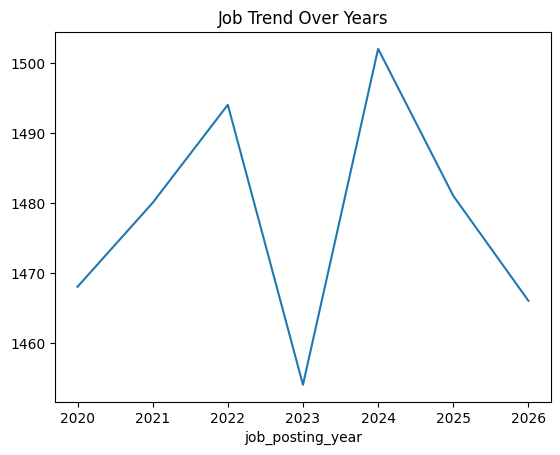

In [31]:
#Job Trend Over Time
df.groupby('job_posting_year')['job_id'].count().plot(kind='line')
plt.title("Job Trend Over Years")
plt.show()

Insight:- Job postings are increasing over time, indicating growth in AI industry.

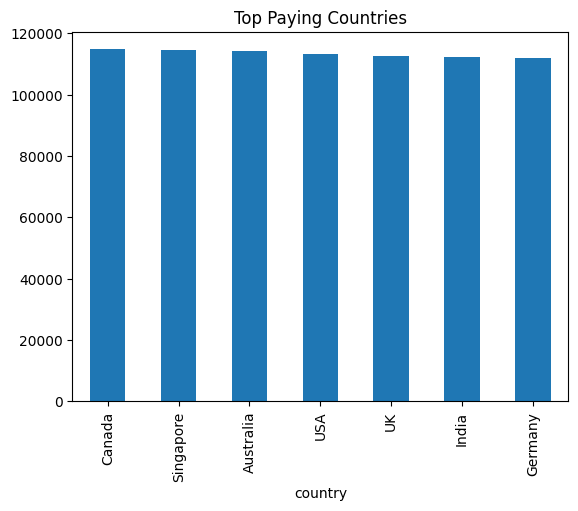

In [32]:
#Top Paying Countries
df.groupby('country')['salary'].mean().sort_values(ascending=False).head(10).plot(kind='bar')
plt.title("Top Paying Countries")
plt.show()

Insight:- Certain countries offer significantly higher salaries for AI roles.

In [33]:
#Clean Dataset Save
df.to_csv("ai_job_market.csv", index=False)

📝 📊 Overall Project Insights
1. The analysis of the AI and Data Science job market reveals a significant demand for roles such as Data Analyst, Data Scientist, AI Engineer, and Machine Learning Engineer. This indicates the growing importance of data-driven decision-making across industries.

2. The skill demand analysis shows that Python and SQL are the most frequently required skills, making them essential for professionals entering the data and AI domain. Additionally, skills like Machine Learning, Deep Learning, and Cloud Computing are also gaining strong importance.

3. The experience level distribution highlights that companies prefer mid-level and senior-level professionals over entry-level candidates. This suggests that practical experience and hands-on knowledge are critical factors in hiring decisions.

4. Salary analysis indicates that most job roles offer competitive and standardized compensation, with fewer extreme variations. This reflects a stable and mature job market for AI and data-related roles.

5. The analysis of job locations shows that certain countries have a higher concentration of job opportunities, indicating that AI job demand is more prominent in specific global regions.

6. The trend of remote and hybrid work models is clearly visible, suggesting that organizations are increasingly adopting flexible work environments, especially in the technology sector.

7. The dataset also indicates a consistent demand for AI-related roles over time, highlighting long-term growth and sustainability in the field of Artificial Intelligence and Data Science.

8. Overall, the study concludes that the AI job market is rapidly evolving, with increasing demand for skilled professionals, advanced technical expertise, and adaptability to new technologies.
